<a href="https://colab.research.google.com/github/GillValenzuela/curso_data_science/blob/master/DS_Ingemat_Clase_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install torch torchvision grad-cam pillow requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.1 MB/s

In [2]:
!pip install -q --upgrade grad-cam

In [3]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt, torch, requests, io
from torchvision import transforms, utils, datasets
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm.auto import tqdm

In [4]:
# --- Data ---
tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])
train_ds = datasets.CIFAR10("data", train=True, download=True, transform=tfms)
test_ds  = datasets.CIFAR10("data", train=False, transform=tfms)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)

100%|██████████| 170M/170M [00:03<00:00, 47.0MB/s]


In [5]:
device   = "cuda" if torch.cuda.is_available() else "cpu"
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,1,1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,1,1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,1,1),nn.BatchNorm2d(128),nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
    def forward(self,x): return self.classifier(self.features(x))

model = SimpleCNN().to(device)
print(f"Parámetros: {sum(p.numel() for p in model.parameters()):,}")

Parámetros: 620,810


In [6]:
# -----------------------------------------------------------
# 4. Pérdida y optimizador
# -----------------------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# -----------------------------------------------------------
# 5. Entrenamiento breve (5 épocas) + validación
# -----------------------------------------------------------
def accuracy(net, loader):
    net.eval(); correct = total = 0
    with torch.no_grad():
        for xb,yb in loader:
            pred = net(xb.to(device)).argmax(1).cpu()
            correct += (pred == yb).sum().item()
            total   += yb.size(0)
    return correct/total

epochs = 5
for ep in range(1, epochs+1):
    model.train()
    for xb,yb in tqdm(train_dl, desc=f"Epoch {ep}/{epochs}", leave=False):
        xb,yb = xb.to(device), yb.to(device)
        loss  = criterion(model(xb), yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    val_acc = accuracy(model, test_dl)
    print(f"Época {ep:02d}  |  val acc: {val_acc*100:.2f}%")

# -----------------------------------------------------------
# 6. Guardar el modelo
# -----------------------------------------------------------
torch.save(model, "cnn_cifar10.pt")
print("✅ Modelo guardado como cnn_cifar10.pt en el directorio de Colab")

Epoch 1/5:   0%|          | 0/1563 [00:00<?, ?it/s]

Época 01  |  val acc: 59.67%


Epoch 2/5:   0%|          | 0/1563 [00:00<?, ?it/s]

Época 02  |  val acc: 68.53%


Epoch 3/5:   0%|          | 0/1563 [00:00<?, ?it/s]

Época 03  |  val acc: 74.10%


Epoch 4/5:   0%|          | 0/1563 [00:00<?, ?it/s]

Época 04  |  val acc: 74.27%


Epoch 5/5:   0%|          | 0/1563 [00:00<?, ?it/s]

Época 05  |  val acc: 76.15%
✅ Modelo guardado como cnn_cifar10.pt en el directorio de Colab


In [7]:
torch.save(model.state_dict(), "cnn_cifar10_sd.pt")

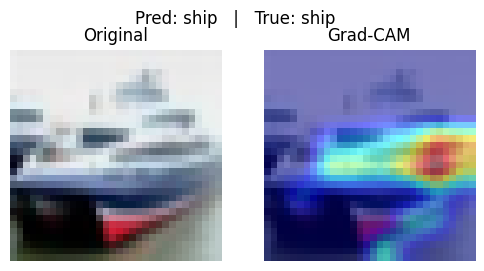

In [9]:
# 1) Cargar la CNN casera entrenada anteriormente
model = torch.load("cnn_cifar10.pt", map_location="cpu",weights_only=False).eval()

# 2) Tomar un lote de prueba (del DataLoader que ya tenemos)
imgs, labels = next(iter(test_dl))
img, label = imgs[1:2], labels[1]

# 3) Preparar Grad-CAM sobre la última conv de nuestra red
target_layer = model.features[-3]          # última Conv (64/128 filtros)
img = img.to(device)

with GradCAM(model=model,
             target_layers=[target_layer]) as cam:
    grayscale_cam = cam(input_tensor=img)[0]

# 4) Des-normalizar para visualizar
def denorm(t):
    mean = torch.tensor((0.4914,0.4822,0.4465)).view(3,1,1)
    std  = torch.tensor((0.2023,0.1994,0.2010)).view(3,1,1)
    return torch.clamp(t * std + mean, 0, 1)

rgb = denorm(img.cpu()[0]).permute(1,2,0).numpy()
cam_img = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

classes = test_ds.classes           # ['airplane', 'automobile', …, 'truck']
model.to(device).eval()
pred_idx = model(img).argmax(1).item()
true_idx = label.item()
pred = model(img).argmax(1).item()


true = label.item()
title = f"Pred: {classes[pred]}   |   True: {classes[true]}"

plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(rgb);     plt.axis("off"); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(cam_img); plt.axis("off"); plt.title("Grad-CAM")
plt.suptitle(title, fontsize=12)
plt.show()

Estrategia 1: Feature Extractor

Entrena 2 – 3 épocas → suele superar el 80 % de accuracy en CIFAR-10.

In [10]:
from torchvision import models

In [11]:
model = models.resnet18(weights="IMAGENET1K_V1")

for p in model.parameters():       # 🔒 congela todo
    p.requires_grad = False

model.fc = nn.Linear(512, 10)      # cabeza nueva
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 104MB/s]


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
model = model.to(device)
model.fc.to(device)

Linear(in_features=512, out_features=10, bias=True)

In [17]:
tf_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),
                         (0.229,0.224,0.225))
])
tf_val = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),
                         (0.229,0.224,0.225))
])

train_ds = datasets.CIFAR10("data", train=True,  download=True, transform=tf_train)
val_ds   = datasets.CIFAR10("data", train=False, download=True, transform=tf_val)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2)

In [14]:
def accuracy(net, loader):
    net.eval(); correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            pred = net(xb.to(device)).argmax(1).cpu()
            correct += (pred == yb).sum().item()
            total   += yb.size(0)
    return correct / total

In [18]:
epochs = 3
for ep in range(1, epochs + 1):
    model.train()
    pbar = tqdm(train_dl, desc=f"Época {ep}/{epochs}")
    for xb, yb in pbar:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        pbar.set_postfix(loss=f"{loss.item():.3f}")
    val_acc = accuracy(model, val_dl)
    print(f"► Val accuracy: {val_acc*100:.2f} %")

# 5. GUARDAR el modelo (opcional) ---------------------------------------
torch.save(model.state_dict(), "resnet18_feature_extractor_cifar10.pt")
print("Modelo guardado.")

Época 1/3:   0%|          | 0/391 [00:00<?, ?it/s]

► Val accuracy: 75.91 %


Época 2/3:   0%|          | 0/391 [00:00<?, ?it/s]

► Val accuracy: 78.19 %


Época 3/3:   0%|          | 0/391 [00:00<?, ?it/s]

► Val accuracy: 78.94 %
Modelo guardado.


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

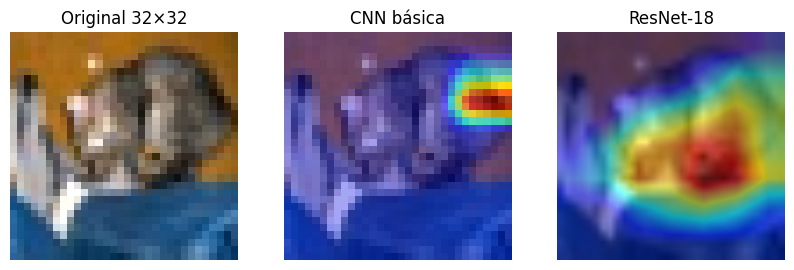

In [19]:
def denorm(t):
    mean = torch.tensor((0.485,0.456,0.406)).view(3,1,1).to(t.device)
    std  = torch.tensor((0.229,0.224,0.225)).view(3,1,1).to(t.device)
    return torch.clamp(t * std + mean, 0, 1)

img, label = val_ds[0]              # misma imagen de test
img = img.unsqueeze(0).to(device)   # (1,3,224,224)

# ---------------- CNN BÁSICA ------------------------------------------
cnn = SimpleCNN().to(device)
cnn.load_state_dict(torch.load("cnn_cifar10_sd.pt", map_location=device))
cnn.eval()
layer_cnn = cnn.features[-3]
# --- transform para la CNN básica (mantiene 32×32) ---
tf_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),
                         (0.2023,0.1994,0.2010))
])

# usa tf_cnn para cargar UNA imagen y pasarla a la CNN
img32, label = test_ds[0]
img32 = img32.unsqueeze(0).to(device)


with GradCAM(model=cnn, target_layers=[layer_cnn]) as cam:
    cam_cnn = cam(input_tensor=img32)[0]

# ---------------- RESNET-18 -------------------------------------------
# transformación para 224×224 (la que usa la ResNet)
to224 = transforms.Resize(224)

img224 = to224(img32.squeeze(0).cpu())        # tensor 3×224×224
img224 = img224.unsqueeze(0).to(device)

resnet = models.resnet18(weights="IMAGENET1K_V1")
resnet.fc = nn.Linear(512,10)
resnet.load_state_dict(torch.load("resnet18_feature_extractor_cifar10.pt",
                                  map_location=device))
resnet = resnet.to(device).eval()
layer_res = resnet.layer4[-1]         # última conv de ResNet

with GradCAM(model=resnet, target_layers=[layer_res]) as cam:
    cam_res = cam(input_tensor=img224)[0]

# ---------------- VISUALIZAR ------------------------------------------
# ---------- CNN básica ----------
rgb32 = denorm(img32[0]).permute(1,2,0).cpu().numpy()      # 32×32×3
overlay_cnn = show_cam_on_image(rgb32, cam_cnn, use_rgb=True)

# ---------- ResNet-18 ----------
rgb224 = denorm(img224[0]).permute(1,2,0).cpu().numpy()    # 224×224×3
overlay_res = show_cam_on_image(rgb224, cam_res, use_rgb=True)

fig, ax = plt.subplots(1,3, figsize=(10,3))
ax[0].imshow(rgb32);          ax[0].set_title("Original 32×32"); ax[0].axis("off")
ax[1].imshow(overlay_cnn);    ax[1].set_title("CNN básica");     ax[1].axis("off")
ax[2].imshow(overlay_res);    ax[2].set_title("ResNet-18");      ax[2].axis("off")

Estrategia 2: Fine-Tuning parcial

3 épocas extractor + 3 épocas fine-tune parcial → suele rozar 90 % en CIFAR-10.

In [20]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(512, 10)

for name, p in model.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        p.requires_grad = True      # 🔓 sólo layer4 + cabeza
    else:
        p.requires_grad = False

optimizer = torch.optim.Adam([
    {"params": model.fc.parameters(),     "lr": 1e-3},
    {"params": model.layer4.parameters(), "lr": 1e-4}
], weight_decay=1e-4)


Estrategia 3:

Requiere 8-10 épocas y buen data-augmentation (RandAug, CutMix) para no sobre-ajustar.

In [23]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(512, 10)

# 🔓 todo entrenable
for p in model.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam([
    {"params": model.fc        , "lr": 1e-3},   # cabeza
    {"params": model.layer4    , "lr": 1e-4},
    {"params": model.layer3    , "lr": 5e-5},
    {"params": model.layer1, "lr": 5e-5},
    {"params": model.layer2, "lr": 5e-5}
], weight_decay=1e-4)


TypeError: 'Linear' object is not iterable

In [24]:
from torchvision import transforms, models
from torchvision.transforms import v2   # ⚠️ torchvision ≥ 0.18

RandAugment se ejecuta antes de pasar a tensor.

Mixup / CutMix operan sobre tensores y devuelven etiquetas soft-labels (distribuciones).

La función de pérdida debe aceptar soft labels: usa criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [25]:
train_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.RandAugment(num_ops=2, magnitude=9),   # ← RandAug
    v2.MixUp(alpha=0.2),                              # ← Mixup
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),
                         (0.229,0.224,0.225))
])

val_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),
                         (0.229,0.224,0.225))
])


Proceso completo: Qué hace RandAugment se aplica en la pipeline de transforms.

Mixup / CutMix se aplican aleatoriamente (70 % de los mini-batches) con alpha = 1.0.

Se usa la estrategia fine-tuning parcial (layer4 + fc) con learning-rates diferenciados.

Después de ~8 époc
as deberías ver una val-accuracy ≈ 92 % (± 1 %) en GPU T4.

Ajusta epochs, alpha, o la probabilidad prob si quieres experimentar.

In [ ]:
# ==========================================================
#  ResNet-18 + RandAugment + Mixup + CutMix  (CIFAR-10)
# ==========================================================
#!pip -q install torch torchvision tqdm

#import torch, torch.nn as nn
#from torchvision import datasets, transforms, models
#from torch.utils.data import DataLoader
#from tqdm.auto import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------
# 1. TRANSFORMS  (224×224   +   RandAugment)
# ----------------------------------------------------------
train_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.RandAugment(num_ops=2, magnitude=9),  # 2 augm. al azar
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),
                         (0.229,0.224,0.225))
])
val_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),
                         (0.229,0.224,0.225))
])

train_ds = datasets.CIFAR10("data", train=True,  download=True, transform=train_tf)
val_ds   = datasets.CIFAR10("data", train=False, download=True, transform=val_tf)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# ----------------------------------------------------------
# 2. MIXUP & CUTMIX (funciones helper — al nivel de batch)
# ----------------------------------------------------------
def _rand_bbox(W, H, lam):
    cut_rat = (1. - lam) ** 0.5
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = random.randint(0, W), random.randint(0, H)
    bbx1 = max(cx - cut_w // 2, 0)
    bby1 = max(cy - cut_h // 2, 0)
    bbx2 = min(cx + cut_w // 2, W)
    bby2 = min(cy + cut_h // 2, H)
    return bbx1, bby1, bbx2, bby2

def mixup_cutmix(batch, alpha=1.0, prob=0.5):
    imgs, labels = batch
    if random.random() > prob:
        return imgs.to(device), labels.to(device)
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    idx = torch.randperm(imgs.size(0))
    imgs2, labels2 = imgs[idx], labels[idx]

    if random.random() < 0.5:          # -------- Mixup --------
        mixed = lam * imgs + (1 - lam) * imgs2
    else:                              # -------- CutMix -------
        bbx1, bby1, bbx2, bby2 = _rand_bbox(imgs.size(3), imgs.size(2), lam)
        mixed = imgs.clone()
        mixed[:, :, bby1:bby2, bbx1:bbx2] = imgs2[:, :, bby1:bby2, bbx1:bbx2]
        lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (imgs.size(-1) * imgs.size(-2)))

    targets = (labels, labels2, lam)   # regresamos tuplas
    return mixed.to(device), targets

def mixup_loss(criterion, pred, targets):
    y1, y2, lam = targets
    return lam * criterion(pred, y1) + (1 - lam) * criterion(pred, y2)

# ----------------------------------------------------------
# 3. MODELO  (ResNet-18 feature-extr. → fine-tune layer4)
# ----------------------------------------------------------
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(512, 10)                       # nueva cabeza

for name, p in model.named_parameters():            # freeze excepto layer4+fc
    if name.startswith("layer4") or name.startswith("fc"):
        p.requires_grad = True
    else:
        p.requires_grad = False

model = model.to(device)

# Optimizer con LR discriminativo
opt = torch.optim.Adam([
    {"params": model.fc.parameters(),     "lr": 1e-3},
    {"params": model.layer4.parameters(), "lr": 1e-4}
], weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# ----------------------------------------------------------
# 4. TRAIN & VALID loops
# ----------------------------------------------------------
def evaluate(net, loader):
    net.eval(); correct=0; total=0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = net(xb).argmax(1)
            correct += (preds==yb).sum().item()
            total   += yb.size(0)
    return correct / total

epochs = 8
for ep in range(1, epochs+1):
    model.train()
    pbar = tqdm(train_dl, desc=f"Ep {ep}/{epochs}", leave=False)
    for imgs, labs in pbar:
        imgs, targets = mixup_cutmix((imgs, labs), alpha=1.0, prob=0.7)
        preds = model(imgs)
        loss  = mixup_loss(criterion, preds, targets) if isinstance(targets, tuple) else criterion(preds, targets)
        opt.zero_grad(); loss.backward(); opt.step()
        pbar.set_postfix(loss=f"{loss.item():.3f}")

    val_acc = evaluate(model, val_dl)
    print(f"Epoch {ep:02d}  •  Val accuracy: {val_acc*100:.2f} %")

# ----------------------------------------------------------
# 5. GUARDAR peso fin-tuneado
# ----------------------------------------------------------
torch.save(model.state_dict(), "resnet18_cifar10_finetuned.pt")
print("✅ Modelo fine-tuneado guardado.")